## Langkah 1 — Setup

Sel ini memasang PySpark (mesin pengolah data besar) di Colab. Tunggu sampai selesai (± 1 menit). Muncul tulisan panjang itu normal.

In [2]:
!pip install -q pyspark

Sel ini menyalakan Spark

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F

# Menyalakan Spark (jalan di dalam Colab, tidak perlu akun cloud)
spark = (
    SparkSession.builder
    .appName("bottleneck_hubs")
    .master("local[*]")
    .config("spark.sql.ansi.enabled", "false")   # supaya timestamp rusak jadi NULL, bukan error
    .getOrCreate()
)
print("Spark siap, versi:", spark.version)

Spark siap, versi: 4.0.4


   ## Langkah 2 — Generate dataset scan_events.csv

   Sel di bawah membuat data simulasi dan menyimpannya sebagai `scan_events.csv` di Colab.

In [ ]:
"""
Seeder: synthetic dataset `scan_events` untuk simulasi analisis dwell time
dan bottleneck hub (PySpark / BigQuery).

Kolom output:
    hub_id      : HUB-001 ... HUB-030
    package_id  : PKG-XXXXXX
    event_type  : "ARRIVAL" | "DEPARTURE"
    timestamp   : YYYY-MM-DD HH:MM:SS

Dependensi: pandas  (pip install pandas)
Jalankan  : python generate_scan_events.py
"""

import random
import string
from datetime import datetime, timedelta

import pandas as pd

# ----------------------------------------------------------------------
# KONFIGURASI
# ----------------------------------------------------------------------
SEED = 42                      # supaya hasil reproducible
NUM_PACKAGES = 5000            # ~2.2 hub/paket x 2 event => ~22 ribu baris (> 10.000)
NUM_HUBS = 30
HUB_IDS = [f"HUB-{i:03d}" for i in range(1, NUM_HUBS + 1)]

# Hub bottleneck: dwell time rata-rata jauh lebih tinggi (30-48 jam)
BOTTLENECK_HUBS = {"HUB-007", "HUB-012", "HUB-018", "HUB-025"}

NORMAL_DWELL_HOURS = (1, 24)       # dwell time hub biasa
BOTTLENECK_DWELL_HOURS = (30, 48)  # dwell time hub bottleneck (rata-rata ~39 jam)
TRANSIT_HOURS = (1, 12)            # waktu perjalanan antar hub (keluar hub A -> tiba hub B)

START_DATE = datetime(2026, 1, 1)
END_DATE = datetime(2026, 3, 31)

# Rasio anomali (total sekitar 13% dari data)
P_MISSING_SCAN = 0.05      # 5% kunjungan hub kehilangan salah satu scan
P_REVERSED_TIME = 0.05     # 5% kunjungan hub memiliki waktu terbalik
P_DUPLICATE_ROWS = 0.03    # 3% dari total baris diduplikasi penuh

TS_FORMAT = "%Y-%m-%d %H:%M:%S"
OUTPUT_FILE = "scan_events.csv"

random.seed(SEED)


# ----------------------------------------------------------------------
# HELPER
# ----------------------------------------------------------------------
def random_start_time() -> datetime:
    """Waktu ARRIVAL pertama paket secara acak di rentang START_DATE - END_DATE."""
    total_seconds = int((END_DATE - START_DATE).total_seconds())
    return START_DATE + timedelta(seconds=random.randint(0, total_seconds))


def generate_package_ids(n: int) -> list:
    """Buat n package_id unik, format PKG-XXXXXX (huruf kapital + angka)."""
    ids = set()
    chars = string.ascii_uppercase + string.digits
    while len(ids) < n:
        ids.add("PKG-" + "".join(random.choices(chars, k=6)))
    return list(ids)


def random_dwell(hub_id: str) -> timedelta:
    """Dwell time normal tergantung jenis hub (bottleneck atau bukan)."""
    low, high = BOTTLENECK_DWELL_HOURS if hub_id in BOTTLENECK_HUBS else NORMAL_DWELL_HOURS
    return timedelta(hours=random.uniform(low, high))


# ----------------------------------------------------------------------
# 1. DATA NORMAL: perjalanan paket melewati 1-4 hub secara berurutan
# ----------------------------------------------------------------------
def build_clean_visits() -> list:
    """
    Return list of dict: {hub_id, package_id, arrival, departure}
    Satu paket melewati 1-4 hub berbeda, waktu berkesinambungan:
    tiba hub A -> keluar hub A -> (transit) -> tiba hub B -> keluar hub B ...
    """
    visits = []
    for pkg_id in generate_package_ids(NUM_PACKAGES):
        n_hubs = random.choices([1, 2, 3, 4], weights=[25, 35, 25, 15])[0]
        route = random.sample(HUB_IDS, n_hubs)  # hub berbeda dalam satu rute
        current_time = random_start_time()

        for hub_id in route:
            arrival = current_time
            departure = arrival + random_dwell(hub_id)
            visits.append(
                {"hub_id": hub_id, "package_id": pkg_id,
                 "arrival": arrival, "departure": departure}
            )
            # Arrival di hub berikutnya = departure hub ini + waktu transit
            current_time = departure + timedelta(hours=random.uniform(*TRANSIT_HOURS))
    return visits


# ----------------------------------------------------------------------
# 2. INJEKSI ANOMALI (Veracity) lalu ubah ke format event
# ----------------------------------------------------------------------
def visits_to_events(visits: list) -> pd.DataFrame:
    rows = []
    for v in visits:
        arrival, departure = v["arrival"], v["departure"]
        r = random.random()

        # --- ANOMALI A: Missing scan -----------------------------------
        # Hanya ada salah satu event (ARRIVAL saja atau DEPARTURE saja).
        if r < P_MISSING_SCAN:
            if random.random() < 0.5:
                events = [("ARRIVAL", arrival)]      # DEPARTURE hilang
            else:
                events = [("DEPARTURE", departure)]  # ARRIVAL hilang

        # --- ANOMALI B: Waktu terbalik ---------------------------------
        # Timestamp ditukar sehingga DEPARTURE lebih awal dari ARRIVAL
        # (dwell time menjadi negatif).
        elif r < P_MISSING_SCAN + P_REVERSED_TIME:
            events = [("ARRIVAL", departure), ("DEPARTURE", arrival)]

        # --- Data normal -----------------------------------------------
        else:
            events = [("ARRIVAL", arrival), ("DEPARTURE", departure)]

        for event_type, ts in events:
            rows.append(
                {"hub_id": v["hub_id"], "package_id": v["package_id"],
                 "event_type": event_type, "timestamp": ts.strftime(TS_FORMAT)}
            )
    return pd.DataFrame(rows)


def inject_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    # --- ANOMALI C: Duplikat penuh ---------------------------------------
    # Sampel sebagian baris lalu tambahkan kembali tanpa perubahan apa pun
    # (semua 4 kolom identik) untuk menguji langkah deduplikasi.
    dupes = df.sample(frac=P_DUPLICATE_ROWS, random_state=SEED)
    return pd.concat([df, dupes], ignore_index=True)


# ----------------------------------------------------------------------
# 3. SIMPAN KE CSV
# ----------------------------------------------------------------------
def save_to_csv(df: pd.DataFrame, path: str = OUTPUT_FILE) -> None:
    df.to_csv(path, index=False)
    print(f"Dataset disimpan ke '{path}' ({len(df):,} baris)")


# ----------------------------------------------------------------------
# MAIN
# ----------------------------------------------------------------------
def main() -> pd.DataFrame:
    visits = build_clean_visits()
    df = visits_to_events(visits)
    df = inject_duplicates(df)

    # Acak urutan baris agar menyerupai log mentah yang tidak terurut
    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

    # --- Ringkasan cepat untuk verifikasi -------------------------------
    print(f"Total baris        : {len(df):,}")
    print(f"Baris duplikat     : {df.duplicated().sum():,}")
    print(f"Package unik       : {df['package_id'].nunique():,}")

    clean = df.drop_duplicates()
    piv = clean.pivot_table(index=["package_id", "hub_id"], columns="event_type",
                            values="timestamp", aggfunc="first")
    print(f"Kunjungan hub tidak lengkap : {piv.isna().any(axis=1).sum():,}")

    ok = piv.dropna().apply(pd.to_datetime)
    dwell = (ok["DEPARTURE"] - ok["ARRIVAL"]).dt.total_seconds() / 3600
    print(f"Kunjungan dengan waktu terbalik: {(dwell < 0).sum():,}")
    top = dwell[dwell >= 0].groupby(level="hub_id").mean().sort_values(ascending=False).head(6)
    print("\nTop hub berdasarkan rata-rata dwell time (jam):")
    print(top.round(1).to_string())

    save_to_csv(df)
    return df


if __name__ == "__main__":
    main()

: 

## Langkah 3 — Baca data & cek struktur (schema)

Data sengaja dibaca **sebagai teks dulu** (belum diubah menjadi tanggal), supaya timestamp yang rusak masih bisa kita deteksi dan hitung.

In [4]:
df_raw = spark.read.csv("scan_events.csv", header=True, inferSchema=False)

print("=== SCHEMA ===")
df_raw.printSchema()

print("=== 5 BARIS PERTAMA ===")
df_raw.show(5, truncate=False)

# Cek apakah 4 kolom yang dibutuhkan ada semua
kolom_wajib = ["hub_id", "package_id", "event_type", "timestamp"]
kolom_hilang = [k for k in kolom_wajib if k not in df_raw.columns]
print("Kolom yang hilang:", kolom_hilang if kolom_hilang else "tidak ada (struktur OK)")

=== SCHEMA ===
root
 |-- hub_id: string (nullable = true)
 |-- package_id: string (nullable = true)
 |-- event_type: string (nullable = true)
 |-- timestamp: string (nullable = true)

=== 5 BARIS PERTAMA ===
+-------+----------+----------+-------------------+
|hub_id |package_id|event_type|timestamp          |
+-------+----------+----------+-------------------+
|HUB-022|PKG-OVCCI6|ARRIVAL   |2026-02-18 14:40:33|
|HUB-011|PKG-9SKDGI|ARRIVAL   |2026-01-28 05:09:13|
|HUB-028|PKG-UYUCEC|ARRIVAL   |2026-01-31 19:12:23|
|HUB-007|PKG-HKBRJI|ARRIVAL   |2026-02-25 19:09:45|
|HUB-019|PKG-MNTFK7|ARRIVAL   |2026-01-21 07:38:36|
+-------+----------+----------+-------------------+
only showing top 5 rows
Kolom yang hilang: tidak ada (struktur OK)


## Langkah 4 — Data Quality Check (pemeriksaan kualitas data)

Bagian ini **hanya memeriksa**, belum membuang apa pun. Kita menghitung: jumlah event, nilai kosong, event_type aneh, timestamp tidak valid, dan duplikat.

In [5]:
# 1) Jumlah event
total_rows = df_raw.count()
print("Total event (baris):", total_rows)

# 2) Nilai kosong per kolom
print("\n=== Nilai kosong per kolom ===")
null_exprs = [
    F.count(F.when(F.col(c).isNull() | (F.trim(F.col(c)) == ""), c)).alias(c)
    for c in df_raw.columns
]
null_row = df_raw.select(null_exprs)
null_row.show()
total_null = sum(null_row.collect()[0])

# 3) Isi kolom event_type (harusnya hanya ARRIVAL dan DEPARTURE)
print("=== Sebaran event_type ===")
df_raw.groupBy("event_type").count().orderBy("event_type").show()
invalid_event_type = df_raw.filter(
    ~F.col("event_type").isin("ARRIVAL", "DEPARTURE") | F.col("event_type").isNull()
).count()
print("event_type tidak valid:", invalid_event_type)

# 4) Timestamp tidak valid (tidak bisa dibaca sebagai YYYY-MM-DD HH:MM:SS)
df_ts = df_raw.withColumn("ts", F.to_timestamp("timestamp", "yyyy-MM-dd HH:mm:ss"))
invalid_timestamp = df_ts.filter(F.col("ts").isNull()).count()
print("Timestamp tidak valid / kosong:", invalid_timestamp)

# 5) Duplicate scan (baris yang sama persis)
distinct_rows = df_raw.distinct().count()
duplicate_rows = total_rows - distinct_rows
print("Baris unik:", distinct_rows)
print("Baris duplikat (kelebihan):", duplicate_rows)

Total event (baris): 23088

=== Nilai kosong per kolom ===
+------+----------+----------+---------+
|hub_id|package_id|event_type|timestamp|
+------+----------+----------+---------+
|     0|         0|         0|        0|
+------+----------+----------+---------+

=== Sebaran event_type ===
+----------+-----+
|event_type|count|
+----------+-----+
|   ARRIVAL|11536|
| DEPARTURE|11552|
+----------+-----+

event_type tidak valid: 0
Timestamp tidak valid / kosong: 0
Baris unik: 22416
Baris duplikat (kelebihan): 672


## Langkah 5 — Bersihkan data dasar

Di sini kita:
- membuang baris duplikat,
- membuang baris dengan `event_type` aneh atau timestamp tidak valid.

Sisanya dipakai untuk membentuk pasangan **ARRIVAL → DEPARTURE**.

In [6]:
df_clean = (
    df_ts
    .dropDuplicates(["hub_id", "package_id", "event_type", "timestamp"])    # buang duplikat
    .filter(F.col("event_type").isin("ARRIVAL", "DEPARTURE"))               # event_type valid saja
    .filter(F.col("ts").isNotNull())                                        # timestamp valid saja
    .filter(F.col("hub_id").isNotNull() & F.col("package_id").isNotNull())
)
clean_rows = df_clean.count()
print("Baris setelah dibersihkan:", clean_rows)
print("Baris yang dibuang:", total_rows - clean_rows)

Baris setelah dibersihkan: 22416
Baris yang dibuang: 672


## Langkah 6 — Hitung Dwell Time per package × hub

Untuk setiap kombinasi `package_id` + `hub_id`, kita cari waktu ARRIVAL dan waktu DEPARTURE, lalu hitung:

**Dwell Time (jam) = DEPARTURE − ARRIVAL**

Setiap pasangan diberi status:
- `VALID` → ARRIVAL dan DEPARTURE lengkap, urutan benar
- `MISSING_ARRIVAL` → hanya ada DEPARTURE
- `MISSING_DEPARTURE` → hanya ada ARRIVAL
- `DEPARTURE_BEFORE_ARRIVAL` → waktu terbalik

In [7]:
pairs = (
    df_clean.groupBy("package_id", "hub_id")
    .agg(
        F.min(F.when(F.col("event_type") == "ARRIVAL", F.col("ts"))).alias("arrival_ts"),
        F.max(F.when(F.col("event_type") == "DEPARTURE", F.col("ts"))).alias("departure_ts"),
    )
    # selisih detik dibagi 3600 = jam
    .withColumn(
        "dwell_hours",
        (F.unix_timestamp("departure_ts") - F.unix_timestamp("arrival_ts")) / 3600,
    )
    # Memberi status kualitas pada tiap pasangan
    .withColumn(
        "pair_status",
        F.when(F.col("arrival_ts").isNull(), "MISSING_ARRIVAL")
         .when(F.col("departure_ts").isNull(), "MISSING_DEPARTURE")
         .when(F.col("departure_ts") < F.col("arrival_ts"), "DEPARTURE_BEFORE_ARRIVAL")
         .otherwise("VALID"),
    )
    .cache()
)

total_pairs = pairs.count()
print("Total pasangan package x hub:", total_pairs)
print("\n=== Kualitas pasangan scan ===")
pairs.groupBy("pair_status").count().orderBy(F.desc("count")).show()

Total pasangan package x hub: 11489

=== Kualitas pasangan scan ===
+--------------------+-----+
|         pair_status|count|
+--------------------+-----+
|               VALID|10318|
|DEPARTURE_BEFORE_...|  609|
|     MISSING_ARRIVAL|  282|
|   MISSING_DEPARTURE|  280|
+--------------------+-----+



Sekarang ambil **hanya pasangan VALID** untuk analisis, lalu cek apakah dwell time-nya masuk akal.

In [8]:
valid_pairs = pairs.filter(F.col("pair_status") == "VALID")
n_valid = valid_pairs.count()
print("Jumlah pasangan valid:", n_valid)

print("\n=== Contoh hasil dwell time ===")
valid_pairs.select("package_id", "hub_id", "arrival_ts", "departure_ts",
                   F.round("dwell_hours", 2).alias("dwell_hours")).show(10, truncate=False)

print("=== Ringkasan dwell time (jam) ===")
valid_pairs.select(
    F.round(F.min("dwell_hours"), 2).alias("min"),
    F.round(F.avg("dwell_hours"), 2).alias("rata_rata"),
    F.round(F.max("dwell_hours"), 2).alias("max"),
).show()

Jumlah pasangan valid: 10318

=== Contoh hasil dwell time ===
+----------+-------+-------------------+-------------------+-----------+
|package_id|hub_id |arrival_ts         |departure_ts       |dwell_hours|
+----------+-------+-------------------+-------------------+-----------+
|PKG-PAYGAA|HUB-015|2026-01-29 03:02:47|2026-01-29 05:38:17|2.59       |
|PKG-IEW6OR|HUB-007|2026-03-30 01:40:59|2026-03-31 15:10:54|37.5       |
|PKG-S62C1J|HUB-015|2026-01-14 04:26:56|2026-01-14 23:47:15|19.34      |
|PKG-M6VDUQ|HUB-014|2026-02-23 09:56:56|2026-02-23 21:46:20|11.82      |
|PKG-9I8YWG|HUB-016|2026-02-01 01:07:04|2026-02-01 03:14:23|2.12       |
|PKG-GOUIFE|HUB-017|2026-03-23 23:57:19|2026-03-24 05:22:42|5.42       |
|PKG-XQ7BZE|HUB-013|2026-02-11 09:26:36|2026-02-12 03:09:08|17.71      |
|PKG-UZY46V|HUB-008|2026-02-11 05:48:03|2026-02-11 15:28:58|9.68       |
|PKG-2LD05N|HUB-003|2026-02-24 07:29:53|2026-02-25 06:30:33|23.01      |
|PKG-RMTN29|HUB-015|2026-02-05 01:53:32|2026-02-05 13:52:45|11

## Langkah 7 — Aggregate per hub & urutkan

Untuk tiap hub kita hitung jumlah paket, rata-rata dwell time, dan median dwell time. Kita juga menghitung **kualitas pasangan scan** (berapa persen pasangan di hub itu yang bermasalah), lalu mengurutkan dari avg dwell tertinggi.

In [9]:
# Statistik dari pasangan yang VALID
hub_stats = valid_pairs.groupBy("hub_id").agg(
    F.count("*").alias("package_count"),
    F.round(F.avg("dwell_hours"), 2).alias("avg_dwell_hours"),
    F.round(F.median("dwell_hours"), 2).alias("median_dwell_hours"),
)

# Kualitas pasangan scan per hub (dari SEMUA pasangan, termasuk yang bermasalah)
hub_quality = pairs.groupBy("hub_id").agg(
    F.count("*").alias("total_pairs"),
    F.sum(F.when(F.col("pair_status") != "VALID", 1).otherwise(0)).alias("invalid_pairs"),
).withColumn("invalid_pct", F.round(F.col("invalid_pairs") / F.col("total_pairs") * 100, 2))

# Gabungkan lalu urutkan: avg_dwell_hours tertinggi -> terendah
hub_result = (
    hub_stats.join(hub_quality, "hub_id")
    .orderBy(F.desc("avg_dwell_hours"))
)

hub_result.show(40, truncate=False)

+-------+-------------+---------------+------------------+-----------+-------------+-----------+
|hub_id |package_count|avg_dwell_hours|median_dwell_hours|total_pairs|invalid_pairs|invalid_pct|
+-------+-------------+---------------+------------------+-----------+-------------+-----------+
|HUB-007|373          |39.41          |39.44             |410        |37           |9.02       |
|HUB-025|327          |39.3           |39.46             |360        |33           |9.17       |
|HUB-012|341          |39.21          |39.62             |387        |46           |11.89      |
|HUB-018|324          |38.93          |39.01             |360        |36           |10.0       |
|HUB-020|348          |13.4           |13.71             |395        |47           |11.9       |
|HUB-003|319          |13.29          |13.67             |358        |39           |10.89      |
|HUB-015|372          |12.82          |12.57             |411        |39           |9.49       |
|HUB-006|330          |12.82  

## Langkah 8 — Top 5 hub bottleneck & simpan ke CSV

Kita ambil 5 hub teratas, lalu menyimpannya ke `top_bottleneck_hubs.csv`.

In [11]:
top_n = 5
top_hubs = hub_result.limit(top_n)
top_hubs.show(truncate=False)

# Ubah ke tabel pandas supaya mudah disimpan & dibuat grafik
top_pd = top_hubs.toPandas()
top_pd.to_csv("top_bottleneck_hubs.csv", index=False)
print("File tersimpan: top_bottleneck_hubs.csv")

+-------+-------------+---------------+------------------+-----------+-------------+-----------+
|hub_id |package_count|avg_dwell_hours|median_dwell_hours|total_pairs|invalid_pairs|invalid_pct|
+-------+-------------+---------------+------------------+-----------+-------------+-----------+
|HUB-007|373          |39.41          |39.44             |410        |37           |9.02       |
|HUB-025|327          |39.3           |39.46             |360        |33           |9.17       |
|HUB-012|341          |39.21          |39.62             |387        |46           |11.89      |
|HUB-018|324          |38.93          |39.01             |360        |36           |10.0       |
|HUB-020|348          |13.4           |13.71             |395        |47           |11.9       |
+-------+-------------+---------------+------------------+-----------+-------------+-----------+

File tersimpan: top_bottleneck_hubs.csv


### Grafik: rata-rata vs median dwell time semua hub

**Yang perlu dilihat:** hub dengan batang tinggi di sisi kiri adalah kandidat bottleneck. Kalau batang *average* dan *median* hampir sama tinggi, artinya keterlambatannya konsisten, bukan karena beberapa paket ekstrem saja.

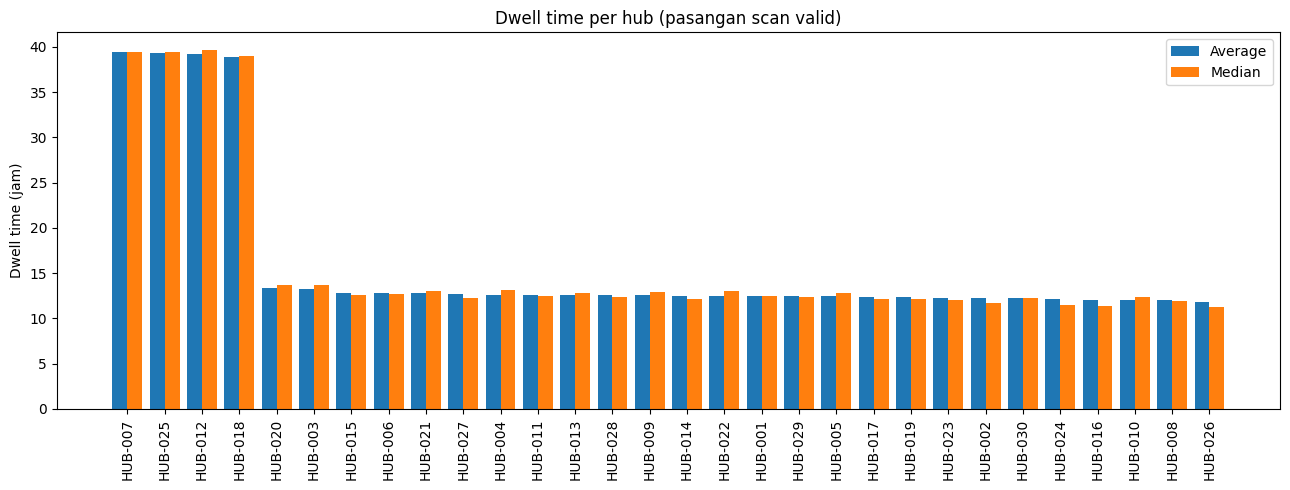

In [12]:
hub_pd = hub_result.toPandas()

fig, ax = plt.subplots(figsize=(13, 5))
x = range(len(hub_pd))
ax.bar([i - 0.2 for i in x], hub_pd["avg_dwell_hours"], width=0.4, label="Average")
ax.bar([i + 0.2 for i in x], hub_pd["median_dwell_hours"], width=0.4, label="Median")
ax.set_xticks(list(x))
ax.set_xticklabels(hub_pd["hub_id"], rotation=90)
ax.set_ylabel("Dwell time (jam)")
ax.set_title("Dwell time per hub (pasangan scan valid)")
ax.legend()
plt.tight_layout()
plt.show()

# Langkah 9 — Buat dokumentasi otomatis

Sel ini menulis file `docs/bigdata-bottleneck-analysis.md`

In [14]:
# ---------- Kumpulkan angka-angka dari hasil analisis ----------
status_pd = pairs.groupBy("pair_status").count().toPandas()
status = dict(zip(status_pd["pair_status"], status_pd["count"]))
n_missing_arr = int(status.get("MISSING_ARRIVAL", 0))
n_missing_dep = int(status.get("MISSING_DEPARTURE", 0))
n_reversed = int(status.get("DEPARTURE_BEFORE_ARRIVAL", 0))
overall_avg = valid_pairs.agg(F.avg("dwell_hours")).collect()[0][0]

def to_md_table(df):
    """Mengubah tabel pandas menjadi tabel Markdown."""
    header = "| " + " | ".join(df.columns) + " |"
    sep = "|" + "|".join(["---"] * len(df.columns)) + "|"
    rows = ["| " + " | ".join(str(v) for v in r) + " |" for r in df.values.tolist()]
    return "\n".join([header, sep] + rows)

# ---------- Bahan untuk paragraf insight ----------
top1 = top_pd.iloc[0]
rest = hub_pd[~hub_pd["hub_id"].isin(top_pd["hub_id"])]
rest_avg = rest["avg_dwell_hours"].mean()
# Hub dianggap "jelas bottleneck" kalau avg dwell-nya >= 1.5x rata-rata hub lainnya
jelas = top_pd[top_pd["avg_dwell_hours"] >= 1.5 * rest_avg]["hub_id"].tolist()
jelas_text = ", ".join(jelas) if jelas else "belum ada yang jelas menonjol"
overall_invalid_pct = (total_pairs - n_valid) / total_pairs * 100
kualitas_text = ("sehingga hasilnya cukup dapat dipercaya"
                 if top1["invalid_pct"] <= overall_invalid_pct + 5 else
                 "yang cukup tinggi sehingga hasilnya perlu diverifikasi dulu")
selisih_pct = abs(top1["avg_dwell_hours"] - top1["median_dwell_hours"]) / top1["avg_dwell_hours"] * 100
pola = ("median-nya hampir sama dengan average, sehingga keterlambatan bersifat konsisten dan bukan karena segelintir paket ekstrem"
        if selisih_pct <= 10 else
        "median-nya cukup berbeda dari average, sehingga ada kemungkinan pengaruh beberapa paket ekstrem (outlier)")

insight = (
    f"{top1['hub_id']} memiliki average dwell time tertinggi sebesar {top1['avg_dwell_hours']:.1f} jam "
    f"(median {top1['median_dwell_hours']:.1f} jam) dari {int(top1['package_count'])} paket valid; {pola}. "
    f"Sebagai pembanding, rata-rata dwell time hub di luar Top {top_n} hanya {rest_avg:.1f} jam. "
    f"Hub yang menonjol jelas di atas hub lain (>= 1,5x rata-rata hub lainnya) adalah: {jelas_text}. "
    f"Kualitas scan di {top1['hub_id']} tercatat {top1['invalid_pct']:.1f}% pasangan bermasalah "
    f"(rata-rata keseluruhan {overall_invalid_pct:.1f}%), {kualitas_text}. "
    f"Investigasi selanjutnya sebaiknya difokuskan pada kapasitas sorting, jumlah tenaga kerja/shift, dan alur "
    f"ARRIVAL-DEPARTURE di hub tersebut, serta memastikan scan DEPARTURE dilakukan tepat waktu."
)

kode_inti = """
# Membuat pasangan ARRIVAL -> DEPARTURE per package x hub
pairs = (df_clean.groupBy("package_id", "hub_id")
    .agg(F.min(F.when(F.col("event_type") == "ARRIVAL", F.col("ts"))).alias("arrival_ts"),
         F.max(F.when(F.col("event_type") == "DEPARTURE", F.col("ts"))).alias("departure_ts"))
    .withColumn("dwell_hours", (F.unix_timestamp("departure_ts") - F.unix_timestamp("arrival_ts")) / 3600))

# Filter -> Group -> Aggregate -> Sort
hub_stats = (pairs.filter(F.col("arrival_ts").isNotNull() & F.col("departure_ts").isNotNull()
                          & (F.col("departure_ts") >= F.col("arrival_ts")))
    .groupBy("hub_id")
    .agg(F.count("*").alias("package_count"),
         F.round(F.avg("dwell_hours"), 2).alias("avg_dwell_hours"),
         F.round(F.median("dwell_hours"), 2).alias("median_dwell_hours"))
    .orderBy(F.desc("avg_dwell_hours")))
""".strip()

md_text = f"""# Analisis Bottleneck Hub — Big Data Fundamentals (Day 18)

## 0. Konsep Singkat: 5 Vs of Big Data & Keterbatasan Pandas
| V | Arti | Contoh pada scan_events |
|---|---|---|
| Volume | Jumlah data sangat besar | Jutaan scan per hari dari banyak hub (dataset simulasi: {total_rows:,} baris) |
| Velocity | Data datang terus-menerus dengan cepat | Scan paket terjadi setiap detik |
| Variety | Bentuk data beragam | Log scan, data hub, GPS, foto paket |
| Veracity | Kualitas/keandalan data | Missing scan, duplikat, timestamp terbalik |
| Value | Nilai bisnis yang digali | Menemukan hub bottleneck untuk perbaikan operasional |

Pandas memuat seluruh data ke memori satu komputer, sehingga lambat atau gagal pada data berukuran besar. PySpark/BigQuery membagi pekerjaan ke banyak mesin (terdistribusi) sehingga mampu menangani data yang jauh lebih besar.

## 1. Dataset & Schema
- File: `scan_events.csv` ({total_rows:,} baris, {len(df_raw.columns)} kolom, {df_raw.select("package_id").distinct().count():,} package unik, {df_raw.select("hub_id").distinct().count()} hub)
- Kolom: `hub_id` (string), `package_id` (string), `event_type` (ARRIVAL/DEPARTURE), `timestamp` (YYYY-MM-DD HH:MM:SS)
- Dibaca di PySpark sebagai teks dahulu, lalu `timestamp` dikonversi dengan `to_timestamp` agar timestamp rusak dapat terdeteksi.

## 2. Data Quality Check
| Pemeriksaan | Hasil |
|---|---|
| Total event | {total_rows:,} |
| Nilai kosong (semua kolom) | {total_null:,} |
| event_type tidak valid | {invalid_event_type:,} |
| Timestamp tidak valid | {invalid_timestamp:,} |
| Baris duplikat | {duplicate_rows:,} |
| Total pasangan package x hub (setelah dedup) | {total_pairs:,} |
| Missing ARRIVAL (hanya ada DEPARTURE) | {n_missing_arr:,} |
| Missing DEPARTURE (hanya ada ARRIVAL) | {n_missing_dep:,} |
| DEPARTURE sebelum ARRIVAL | {n_reversed:,} |
| Pasangan VALID dipakai analisis | {n_valid:,} |

Langkah pembersihan: duplikat dibuang, event/timestamp tidak valid dibuang, dan hanya pasangan berstatus `VALID` yang dipakai menghitung dwell time.

## 3. Query / Kode PySpark
Kode lengkap ada di `analysis/bottleneck_analysis.ipynb`. Inti perhitungannya:

```python
{kode_inti}
```

## 4. Hasil Perhitungan Dwell Time
Dwell Time (jam) = DEPARTURE - ARRIVAL, dihitung per kombinasi package_id x hub_id dari pasangan valid.
Rata-rata dwell time keseluruhan: **{overall_avg:.2f} jam**.

## 5. Top {top_n} Bottleneck Hubs
{to_md_table(top_pd)}

Keterangan: `invalid_pct` = persentase pasangan scan bermasalah di hub tersebut.

## 6. Business Insight & Rekomendasi Investigasi
{insight}

**Rekomendasi investigasi:**
1. Periksa kapasitas dan antrean area sorting di hub teratas pada jam sibuk.
2. Periksa jumlah petugas/shift dan jadwal keberangkatan armada di hub tersebut.
3. Audit kepatuhan scan DEPARTURE dan perbaiki penyebab missing/duplicate scan.
4. Bandingkan alur ARRIVAL-DEPARTURE hub bottleneck dengan hub normal sebagai acuan.
"""

with open("docs/bigdata-bottleneck-analysis.md", "w", encoding="utf-8") as f:
    f.write(md_text)

print("Dokumentasi tersimpan: docs/bigdata-bottleneck-analysis.md\n")
print(md_text)

Dokumentasi tersimpan: docs/bigdata-bottleneck-analysis.md

# Analisis Bottleneck Hub — Big Data Fundamentals (Day 18)

## 0. Konsep Singkat: 5 Vs of Big Data & Keterbatasan Pandas
| V | Arti | Contoh pada scan_events |
|---|---|---|
| Volume | Jumlah data sangat besar | Jutaan scan per hari dari banyak hub (dataset simulasi: 23,088 baris) |
| Velocity | Data datang terus-menerus dengan cepat | Scan paket terjadi setiap detik |
| Variety | Bentuk data beragam | Log scan, data hub, GPS, foto paket |
| Veracity | Kualitas/keandalan data | Missing scan, duplikat, timestamp terbalik |
| Value | Nilai bisnis yang digali | Menemukan hub bottleneck untuk perbaikan operasional |

Pandas memuat seluruh data ke memori satu komputer, sehingga lambat atau gagal pada data berukuran besar. PySpark/BigQuery membagi pekerjaan ke banyak mesin (terdistribusi) sehingga mampu menangani data yang jauh lebih besar.

## 1. Dataset & Schema
- File: `scan_events.csv` (23,088 baris, 4 kolom, 5,000 package unik,